In [5]:
import getpass
import os
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_deepseek import ChatDeepSeek

deepseek_api_key = "sk-f46c7e2053764299ace45b6e3d98de77"
base_url = "https://api.deepseek.com"

# model = ChatOpenAI(model="gpt-4o")
if not os.getenv("DEEPSEEK_API_KEY"):
    os.environ["DEEPSEEK_API_KEY"] = deepseek_api_key

llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)


# @tool
# def magic_function(input: int) -> int:
#     """Applies a magic function to an input."""
#     return input + 2


# tools = [magic_function]


# query = "what is the value of magic_function(77)?"


In [6]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

# 1. 定义状态类型 (TypedDict)
class AgentState(TypedDict):
    input: str
    sub_tasks: Annotated[list[str], lambda a, b: a + [b]]  # 动态添加子任务
    current_task: int
    results: Annotated[list[str], lambda a, b: a + [b]]    # 动态添加结果
    needs_revision: bool
    review_count: int

# 2. 初始化模型
# llm = ChatOpenAI(model="gpt-4-turbo")

# 3. 定义节点函数 (新版API)
def task_planner(state: AgentState) -> dict:
    """任务分解节点"""
    response = llm.invoke(
        f"将任务拆解为1-3个子任务，用'- '开头分行列出:\n{state['input']}"
    )
    tasks = [line[2:] for line in response.content.splitlines() if line.startswith('- ')]
    return {
        "sub_tasks": tasks,
        "current_task": 0,
        "results": [],
        "needs_revision": False,
        "review_count": 0
    }

def executor(state: AgentState) -> dict:
    """任务执行节点"""
    task = state["sub_tasks"][state["current_task"]]
    response = llm.invoke(f"执行任务: {task}")
    return {"results": response.content}

def reviewer(state: AgentState) -> dict:
    """结果审核节点"""
    result = state["results"][-1]
    response = llm.invoke(
        "检查结果质量。若存在以下问题需重做:\n"
        "1. 信息不完整\n2. 逻辑错误\n3. 格式混乱\n"
        f"只需回答 'YES' 或 'NO':\n{result}"
    )
    return {"needs_revision": "YES" in response.content.upper()}

# 4. 构建图
workflow = StateGraph(AgentState)

# 添加节点
workflow.add_node("task_planner", task_planner)
workflow.add_node("executor", executor)
workflow.add_node("reviewer", reviewer)

# 设置入口点
workflow.set_entry_point("task_planner")

# 添加固定边
workflow.add_edge("task_planner", "executor")
workflow.add_edge("executor", "reviewer")

# 添加条件边
def route_review(state: AgentState) -> str:
    if state["needs_revision"] and state["review_count"] < 3:
        return "executor"  # 需要重做
    elif state["current_task"] < len(state["sub_tasks"]) - 1:
        return "executor"  # 继续下一个任务
    return END  # 结束

workflow.add_conditional_edges(
    "reviewer",
    route_review,
    {"executor": "executor", END: END}
)

# 5. 编译图
app = workflow.compile()

# 6. 执行
inputs = {"input": "写一篇LangGraph多Agent系统的技术文章，包含代码示例"}
result = app.invoke(inputs)

print("最终结果:")
for i, res in enumerate(result["results"]):
    print(f"\n任务 {i+1}:\n{res}")

最终结果:

任务 1:
[]

任务 2:
# LangGraph多Agent系统详解

## 1. LangGraph多Agent系统基本概念和架构

LangGraph是一个基于LangChain构建的框架，专门用于创建多Agent系统和复杂的工作流。它通过图形化的方式组织多个AI Agent之间的交互，使开发者能够构建复杂的协作系统。

### 核心概念

- **Agent(代理)**: 具有特定能力的独立AI实体，可以执行任务、做出决策或与其他Agent交互
- **Node(节点)**: 工作流中的基本执行单元，可以是Agent或函数
- **Edge(边)**: 定义节点之间的流转条件和路径
- **State(状态)**: 在整个工作流中传递的共享数据上下文

### 系统架构

LangGraph多Agent系统的典型架构包含以下组件：

1. **Agent池**: 包含多个具有不同专长的Agent
2. **协调器**: 管理Agent间的通信和任务分配
3. **工作流引擎**: 执行预定义或动态生成的工作流
4. **状态存储器**: 维护系统运行时的共享状态
5. **接口层**: 提供与外部系统的交互能力

```
[用户输入] → [协调器] → [Agent选择] → [任务执行] → [结果聚合] → [输出]
                ↑           ↓               ↑
                └──[状态存储器]←──┘
```

## 2. 多Agent协作实现方式与代码示例

### 基本协作模式

#### 顺序执行模式

```python
from langgraph.graph import Graph
from langchain.agents import create_react_agent
from langchain_core.tools import tool

# 定义工具
@tool
def search(query: str):
    """执行搜索"""
    return f"搜索结果: {query}"

# 创建两个Agent
agent1 = create_react_agent(llm, [search], "你是一个研究助手")
agent

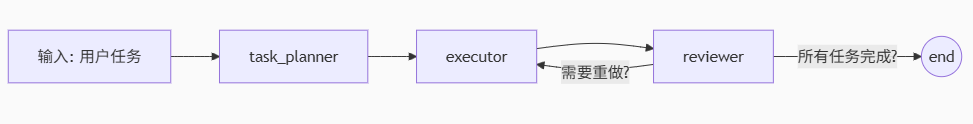